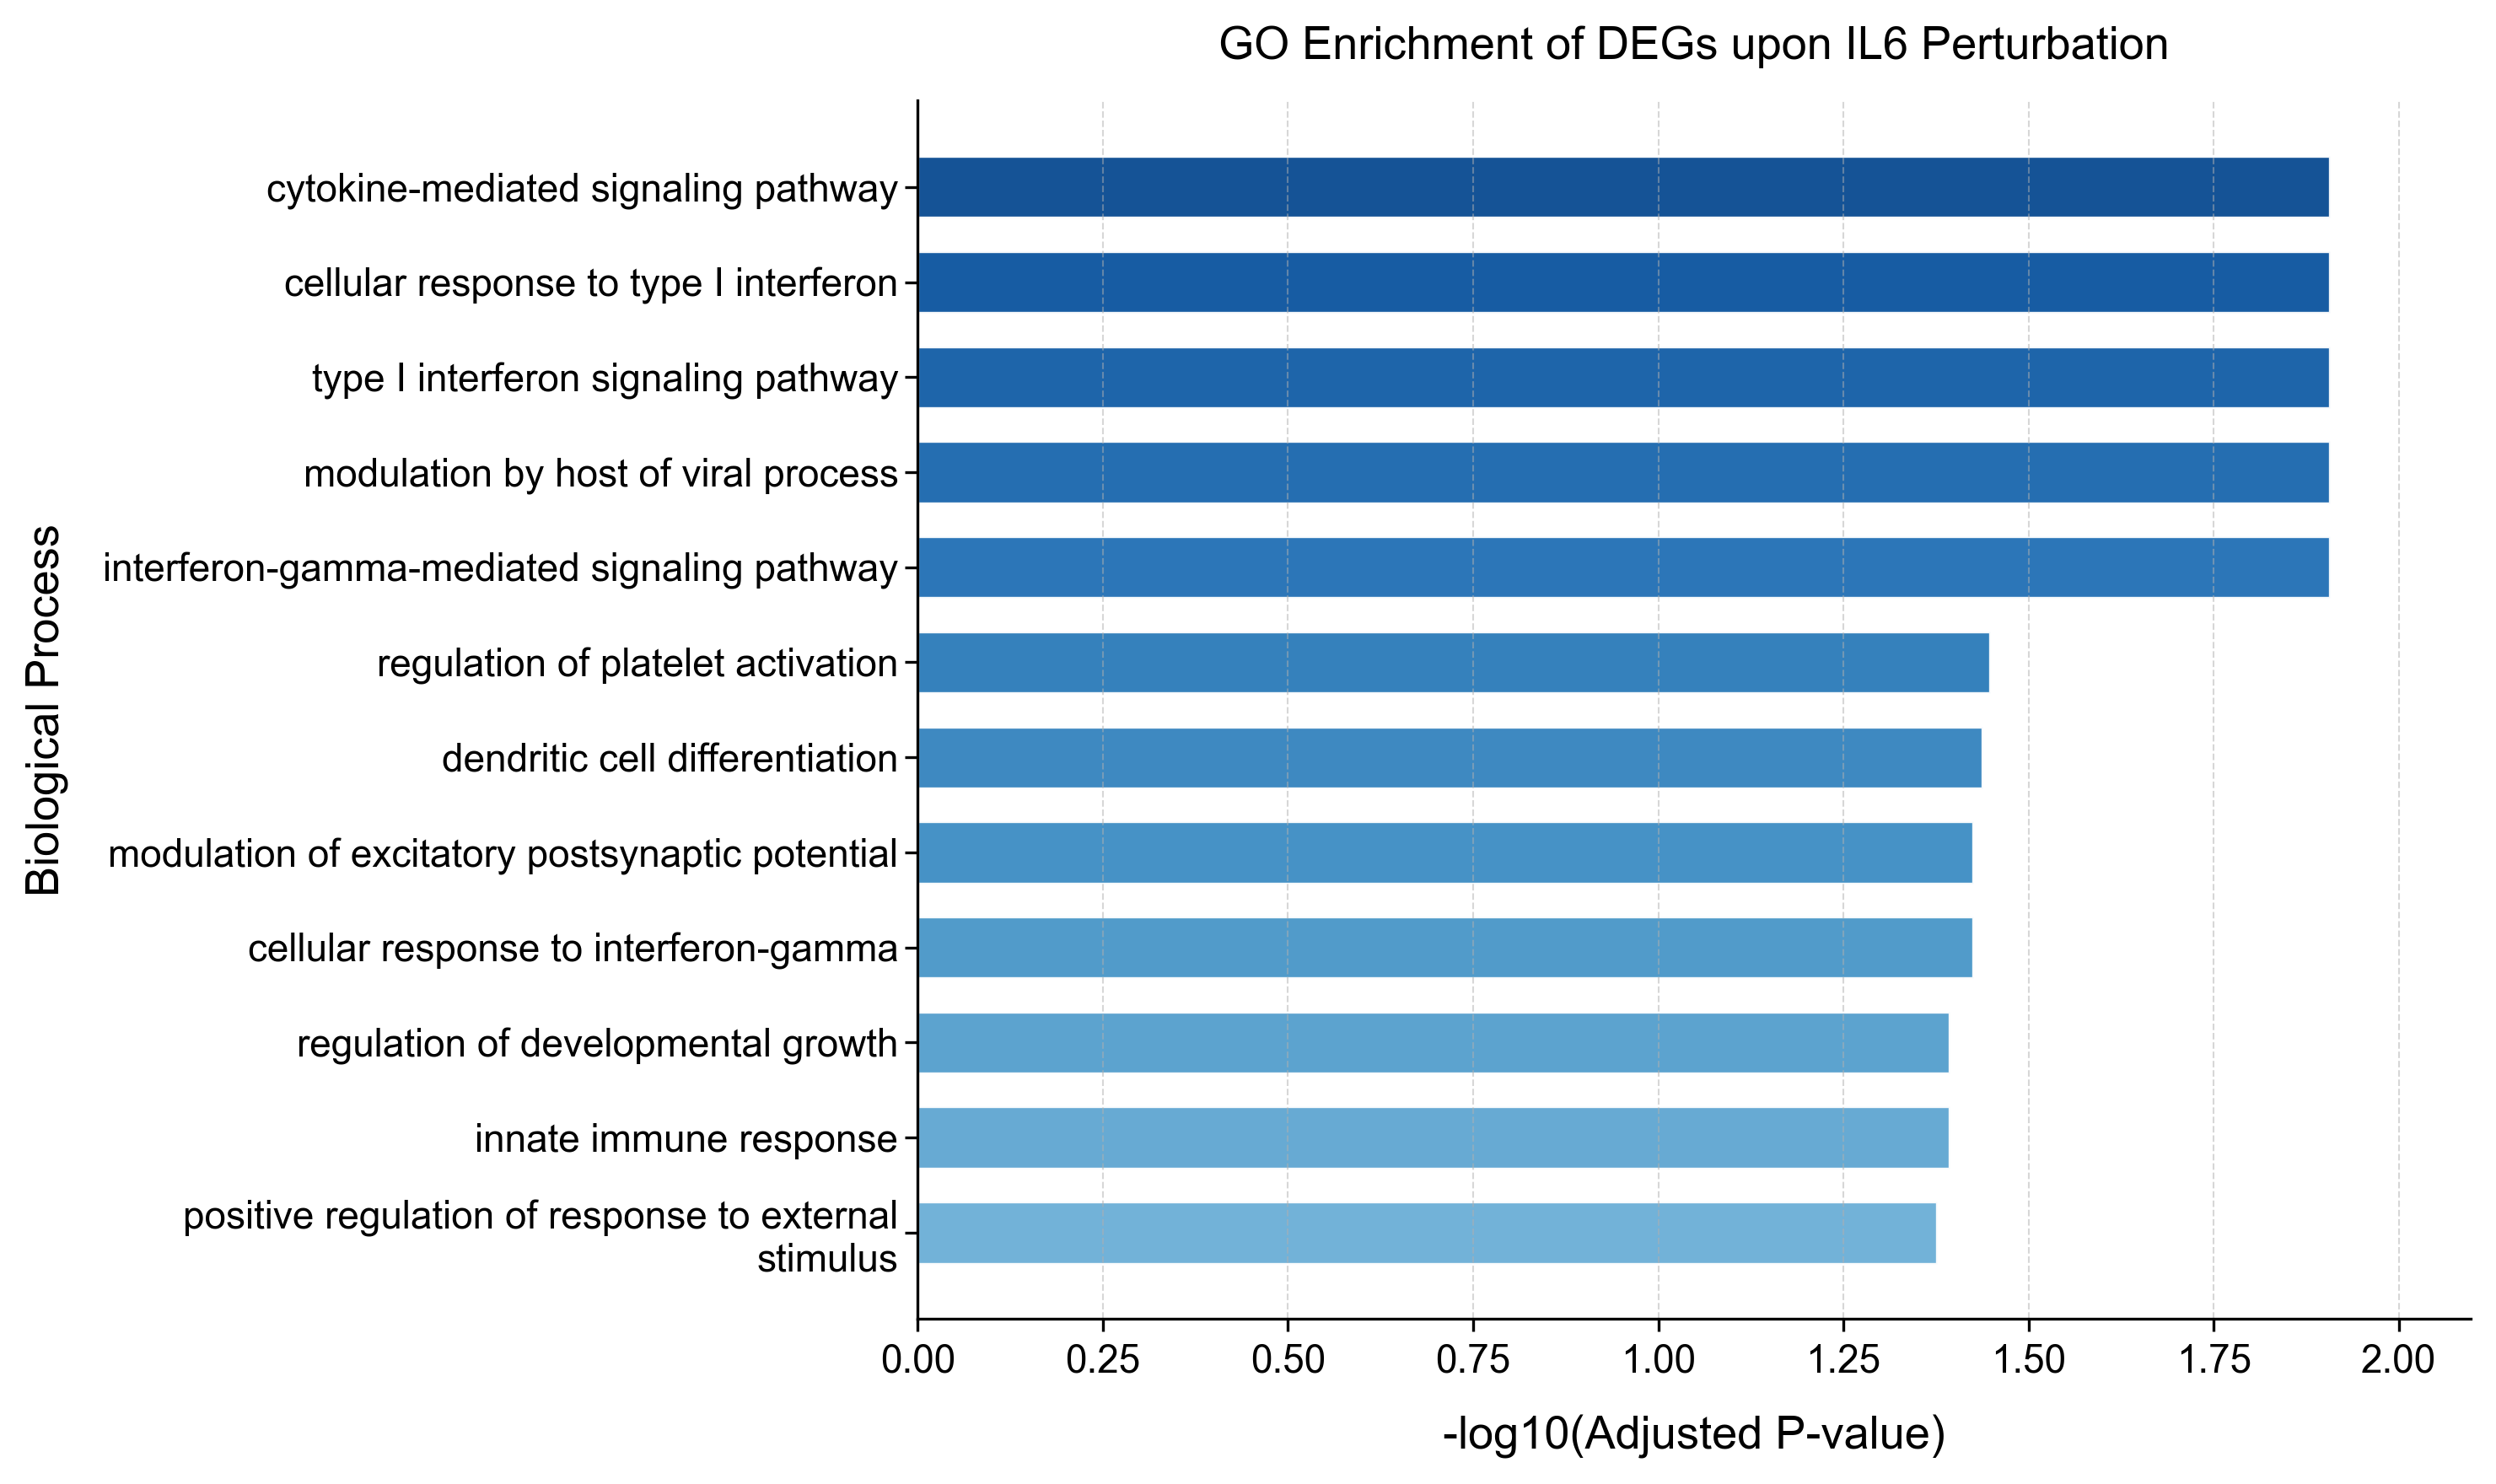

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re

# ---------------------- CUSTOM PARAMETERS ----------------------
PERTURB_GENE = 'IL6'
CSV_PATH = "IL6_go_enrichment.csv"
SAVE_DIR = "images/"
PADJ_THRESHOLD = 0.05
TOP_N = 12

# Plot layout parameters
Y_SCALE = 0.35
HEIGHT_RATIO = 0.65
MAX_TERM_LENGTH = 50
FIG_WIDTH = 10
DPI_VALUE = 300

# Font and style settings
FONT_FAMILY = "Arial"
FONT_SIZE_GLOBAL = 12
FONT_SIZE_AXIS = 13
FONT_SIZE_TICK = 11
FONT_SIZE_TITLE = 13

os.makedirs(SAVE_DIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)
df_sig = df[df["Adjusted P-value"] < PADJ_THRESHOLD].copy()

if len(df_sig) == 0:
    print("No significant enrichment results!")
    exit()

df_sig["-log10(Padj)"] = -np.log10(df_sig["Adjusted P-value"])
df_plot = df_sig.sort_values("-log10(Padj)", ascending=False).head(TOP_N)
df_plot = df_plot.iloc[::-1]

def clean_and_wrap_term(term, max_len):
    term_clean = re.sub(r"\s*\(GO:\d+\)", "", term)

    if len(term_clean) > max_len:
        words = term_clean.split()
        lines = []
        current = ""
        for w in words:
            if len(current + " " + w) < max_len:
                current += " " + w
            else:
                lines.append(current.strip())
                current = w
        lines.append(current.strip())
        return "\n".join(lines)
    return term_clean


df_plot["Term_clean"] = df_plot["Term"].apply(lambda x: clean_and_wrap_term(x, MAX_TERM_LENGTH))

FIG_HEIGHT = max(5, len(df_plot) * 0.5)

plt.rcParams.update({
    "font.family": FONT_FAMILY,
    "font.size": FONT_SIZE_GLOBAL,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "black",
    "figure.dpi": DPI_VALUE,
    "figure.figsize": (FIG_WIDTH, FIG_HEIGHT),
    "savefig.bbox": "tight"
})

fig, ax = plt.subplots()
colors = plt.cm.Blues(np.linspace(0.5, 0.9, len(df_plot)))
y = np.arange(len(df_plot)) * Y_SCALE

ax.barh(
    y=y,
    width=df_plot["-log10(Padj)"],
    height=Y_SCALE * HEIGHT_RATIO,
    color=colors,
    edgecolor="white",
    linewidth=0.8,
    alpha=0.95
)

ax.set_yticks(y)
ax.set_yticklabels(df_plot["Term_clean"])

ax.set_xlabel("-log10(Adjusted P-value)", fontsize=FONT_SIZE_AXIS, labelpad=10)
ax.set_ylabel("Biological Process", fontsize=FONT_SIZE_AXIS, labelpad=10)
ax.set_title(f"GO Enrichment of DEGs upon {PERTURB_GENE} Perturbation", fontsize=FONT_SIZE_TITLE, pad=12)

ax.tick_params(axis="x", labelsize=FONT_SIZE_TICK)
ax.tick_params(axis="y", labelsize=FONT_SIZE_TICK, pad=2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, df_plot["-log10(Padj)"].max() * 1.1)
ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout(pad=1)

png_path = os.path.join(SAVE_DIR, "enrichment_barh_final.png")
plt.savefig(png_path, dpi=DPI_VALUE)
plt.show()
plt.close()

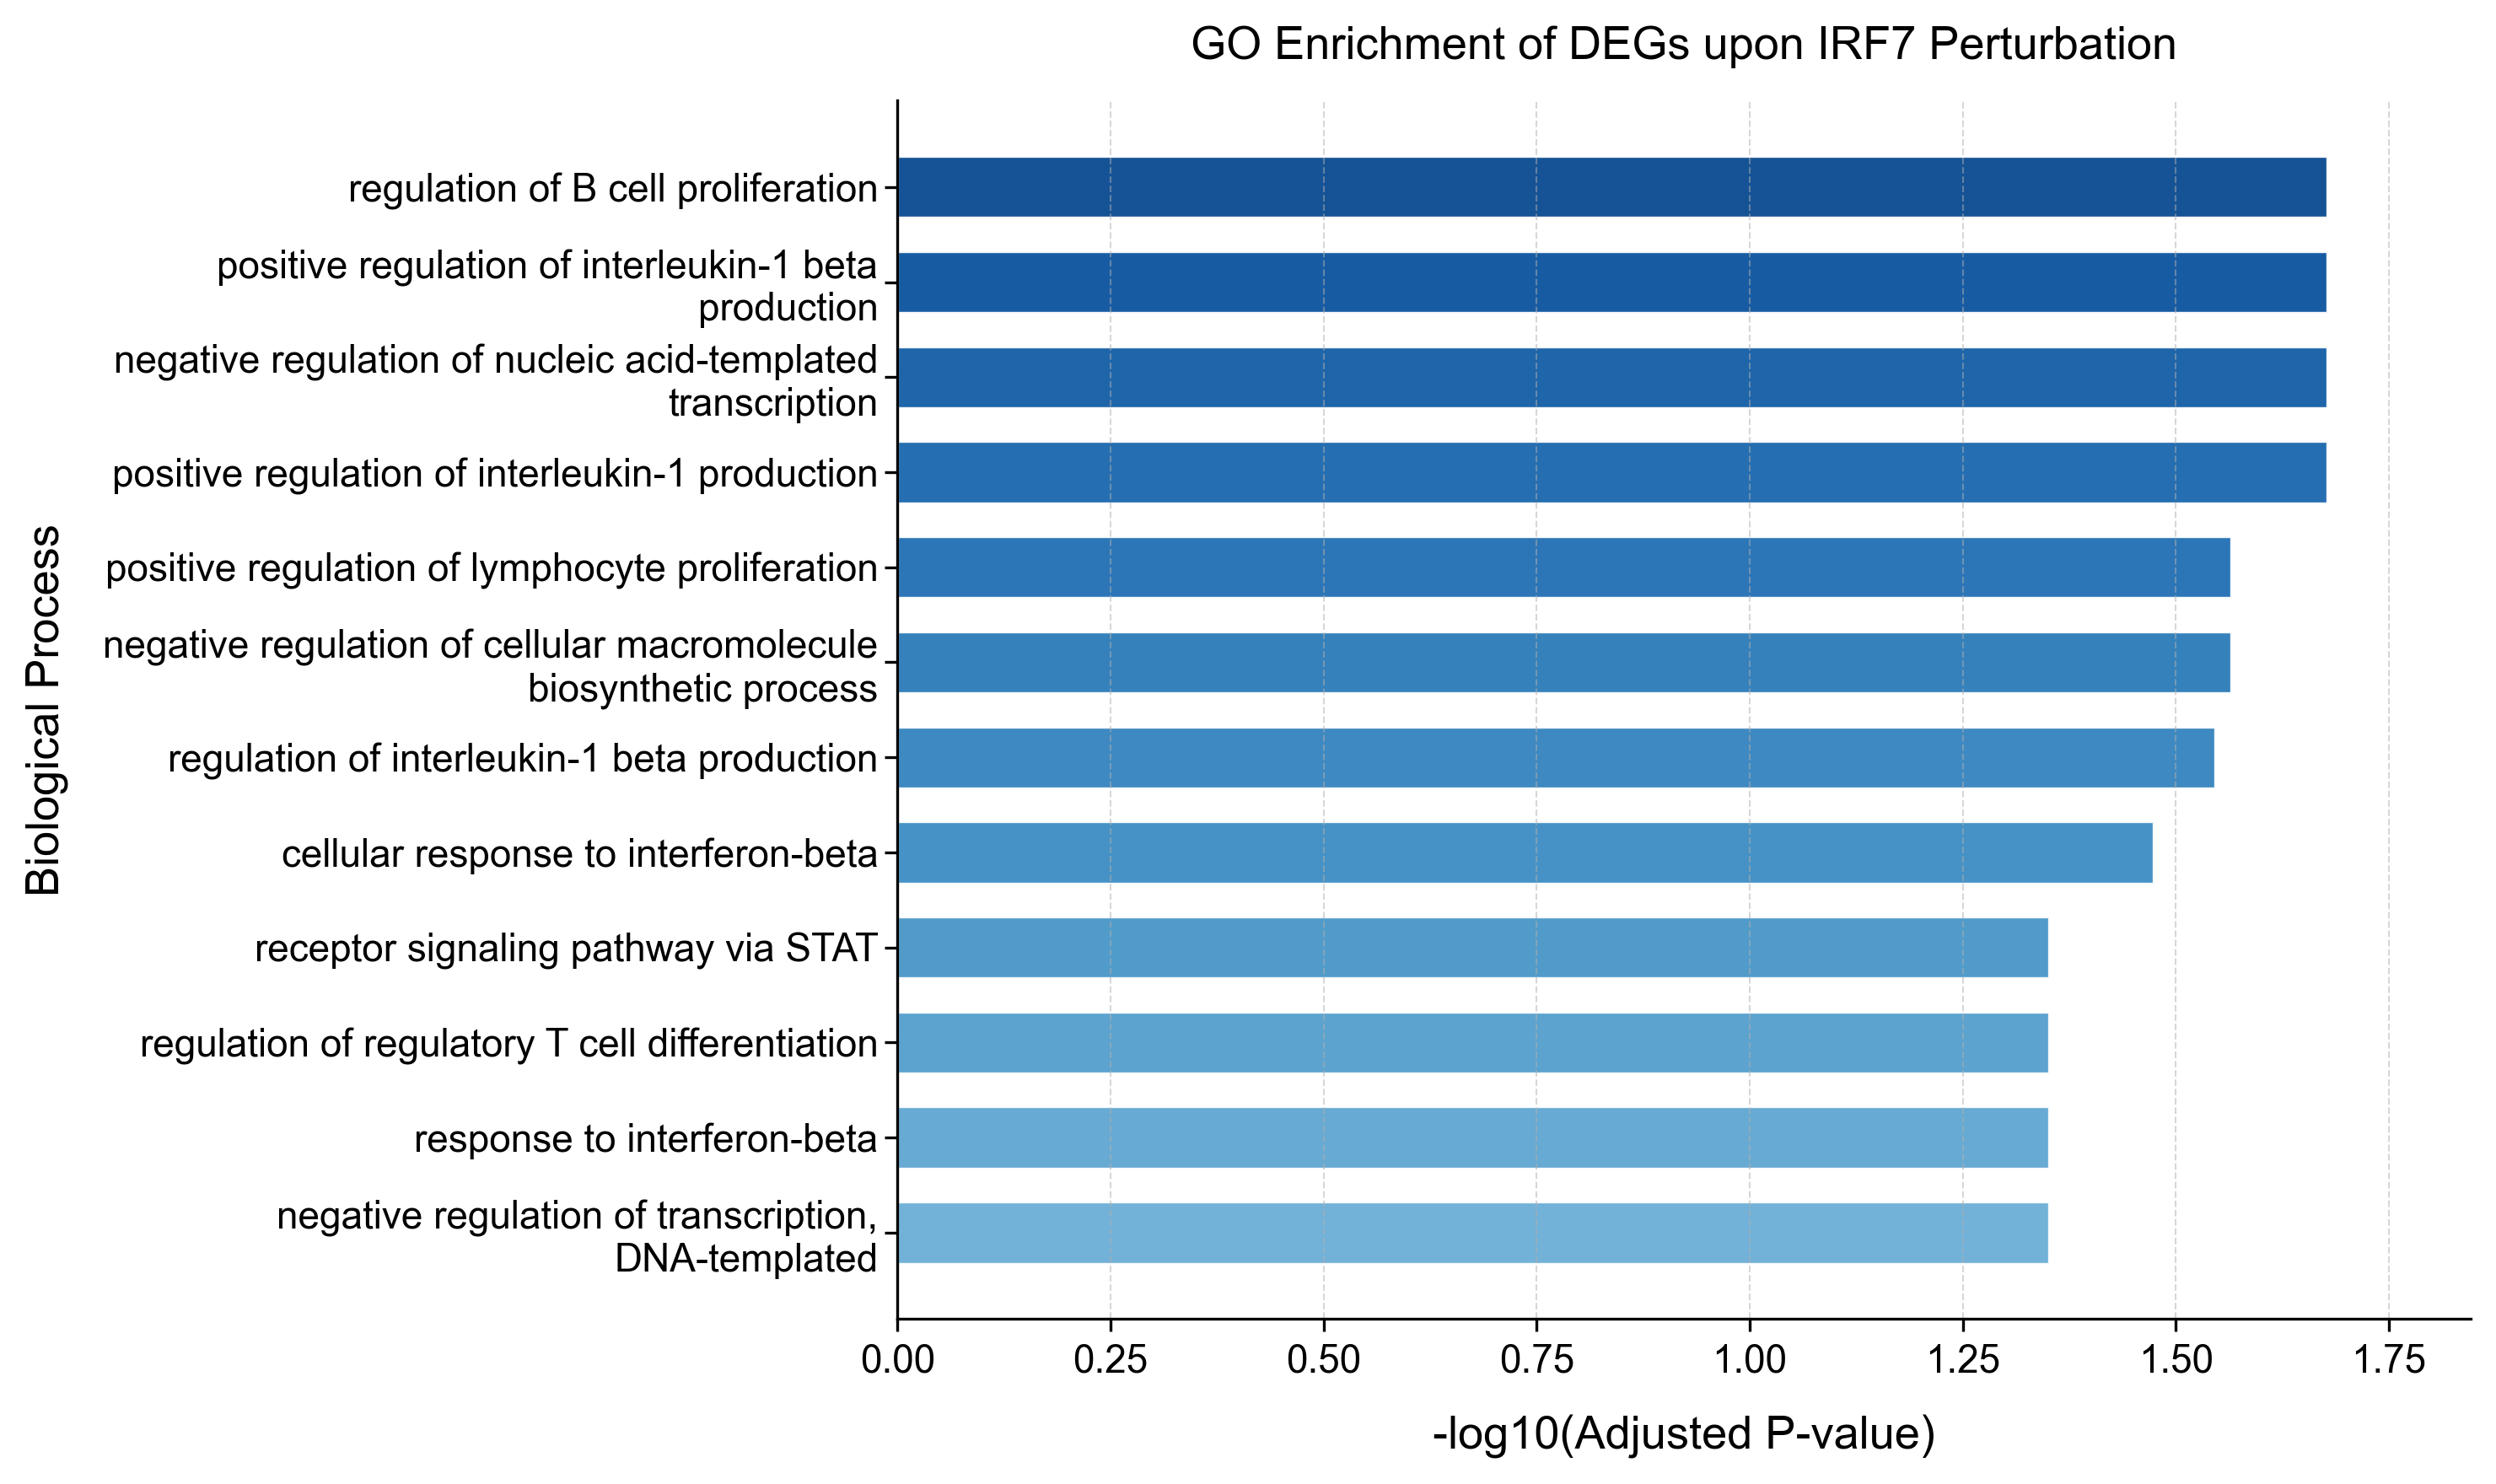

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re

# ---------------------- CUSTOM PARAMETERS ----------------------
PERTURB_GENE = 'IRF7'
CSV_PATH = "IRF7go_enrichment.csv"
SAVE_DIR = "images/"
PADJ_THRESHOLD = 0.05
TOP_N = 12

# Plot layout parameters
Y_SCALE = 0.35
HEIGHT_RATIO = 0.65
MAX_TERM_LENGTH = 50
FIG_WIDTH = 10
DPI_VALUE = 300

# Font and style settings
FONT_FAMILY = "Arial"
FONT_SIZE_GLOBAL = 12
FONT_SIZE_AXIS = 13
FONT_SIZE_TICK = 11
FONT_SIZE_TITLE = 13

os.makedirs(SAVE_DIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)
df_sig = df[df["Adjusted P-value"] < PADJ_THRESHOLD].copy()

if len(df_sig) == 0:
    print("No significant enrichment results!")
    exit()

df_sig["-log10(Padj)"] = -np.log10(df_sig["Adjusted P-value"])
df_plot = df_sig.sort_values("-log10(Padj)", ascending=False).head(TOP_N)
df_plot = df_plot.iloc[::-1]

def clean_and_wrap_term(term, max_len):
    term_clean = re.sub(r"\s*\(GO:\d+\)", "", term)

    if len(term_clean) > max_len:
        words = term_clean.split()
        lines = []
        current = ""
        for w in words:
            if len(current + " " + w) < max_len:
                current += " " + w
            else:
                lines.append(current.strip())
                current = w
        lines.append(current.strip())
        return "\n".join(lines)
    return term_clean


df_plot["Term_clean"] = df_plot["Term"].apply(lambda x: clean_and_wrap_term(x, MAX_TERM_LENGTH))

FIG_HEIGHT = max(5, len(df_plot) * 0.5)

plt.rcParams.update({
    "font.family": FONT_FAMILY,
    "font.size": FONT_SIZE_GLOBAL,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "black",
    "figure.dpi": DPI_VALUE,
    "figure.figsize": (FIG_WIDTH, FIG_HEIGHT),
    "savefig.bbox": "tight"
})

fig, ax = plt.subplots()
colors = plt.cm.Blues(np.linspace(0.5, 0.9, len(df_plot)))
y = np.arange(len(df_plot)) * Y_SCALE

ax.barh(
    y=y,
    width=df_plot["-log10(Padj)"],
    height=Y_SCALE * HEIGHT_RATIO,
    color=colors,
    edgecolor="white",
    linewidth=0.8,
    alpha=0.95
)

ax.set_yticks(y)
ax.set_yticklabels(df_plot["Term_clean"])

ax.set_xlabel("-log10(Adjusted P-value)", fontsize=FONT_SIZE_AXIS, labelpad=10)
ax.set_ylabel("Biological Process", fontsize=FONT_SIZE_AXIS, labelpad=10)
ax.set_title(f"GO Enrichment of DEGs upon {PERTURB_GENE} Perturbation", fontsize=FONT_SIZE_TITLE, pad=12)

ax.tick_params(axis="x", labelsize=FONT_SIZE_TICK)
ax.tick_params(axis="y", labelsize=FONT_SIZE_TICK, pad=2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, df_plot["-log10(Padj)"].max() * 1.1)
ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout(pad=1)

png_path = os.path.join(SAVE_DIR, "enrichment_barh_final2.png")
plt.savefig(png_path, dpi=DPI_VALUE)
plt.show()
plt.close()